<h1>Hybrid Deep Learning Framework for Automated Lung Cancer Diagnosis</h1>

In [17]:
import os
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt

print("TensorFlow version:", tf.__version__)
print("Num GPUs Available:", len(tf.config.list_physical_devices('GPU')))

TensorFlow version: 2.18.0
Num GPUs Available: 2


In [3]:
BASE_DIR = "/kaggle/input/iqothnccd-lung-cancer-dataset/The IQ-OTHNCCD lung cancer dataset/The IQ-OTHNCCD lung cancer dataset"

data_paths = {
    "Benign": os.path.join(BASE_DIR, "Bengin cases"),
    "Malignant": os.path.join(BASE_DIR, "Malignant cases"),
    "Normal": os.path.join(BASE_DIR, "Normal cases")
}

In [4]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 16

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=15,
    zoom_range=0.2,
    horizontal_flip=True
)

train_data = datagen.flow_from_directory(
    BASE_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    subset="training",
    class_mode="categorical"
)

val_data = datagen.flow_from_directory(
    BASE_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    subset="validation",
    class_mode="categorical"
)

Found 878 images belonging to 3 classes.
Found 219 images belonging to 3 classes.


In [5]:
inception_base = InceptionV3(
    include_top=False,
    weights='imagenet',
    input_shape=(224, 224, 3)
)
inception_base.trainable = False

I0000 00:00:1761457171.337953      37 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1761457171.338694      37 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [6]:
def vit_block(inputs, num_heads=4, projection_dim=256, transformer_layers=4):
    # Project CNN features (2048) to a lower dimension
    x = layers.Dense(projection_dim)(inputs)  # (None, 5, 5, 256)
    x = layers.Reshape((-1, projection_dim))(x)  # (None, 25, 256)
    
    for _ in range(transformer_layers):
        attn_out = layers.MultiHeadAttention(num_heads=num_heads, key_dim=projection_dim)(x, x)
        x = layers.Add()([x, attn_out])
        x = layers.LayerNormalization(epsilon=1e-6)(x)

        ffn = keras.Sequential([
            layers.Dense(projection_dim * 2, activation="relu"),
            layers.Dense(projection_dim)
        ])
        x_ffn = ffn(x)
        x = layers.Add()([x, x_ffn])
        x = layers.LayerNormalization(epsilon=1e-6)(x)
    
    x = layers.GlobalAveragePooling1D()(x)
    return x

In [7]:
inputs = keras.Input(shape=(224, 224, 3))
x = inception_base(inputs, training=False)
x = vit_block(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(3, activation='softmax')(x)

hybrid_model = keras.Model(inputs, outputs, name="InceptionV3_ViT_Hybrid")

In [8]:
hybrid_model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

hybrid_model.summary()

Model: "InceptionV3_ViT_Hybrid"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ inception_v3        │ (None, 5, 5,      │ 21,802,784 │ input_layer_1[0]… │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 5, 5, 256) │    524,544 │ inception_v3[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 25, 256)   │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 25, 256)   │  1,051,904 │ reshape[0][0],    │
│ (MultiHeadAttentio… │                   │            │ reshape[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 25, 256)   │          0 │ reshape[0][0],    │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 25, 256)   │        512 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential          │ (None, 25, 256)   │    262,912 │ layer_normalizat… │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 25, 256)   │          0 │ layer_normalizat… │
│                     │                   │            │ sequential[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 25, 256)   │        512 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 25, 256)   │  1,051,904 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 25, 256)   │          0 │ layer_normalizat… │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 25, 256)   │        512 │ add_2[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_1        │ (None, 25, 256)   │    262,912 │ layer_normalizat… │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_3 (Add)         │ (None, 25, 256)   │          0 │ layer_normalizat… │
│                     │                   │            │ sequential_1[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 25, 256)   │        512 │ add_3[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 25, 256)   │  1,051,904 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 27,657,251 (105.50 MB)

 Trainable params: 5,854,467 (22.33 MB)

 Non-trainable params: 21,802,784 (83.17 MB)

In [9]:
EPOCHS = 30
history = hybrid_model.fit(
    train_data,
    validation_data=val_data,
    epochs=EPOCHS
)

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30


I0000 00:00:1761457202.695610     117 service.cc:148] XLA service 0x7a40d0002250 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1761457202.696492     117 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1761457202.696521     117 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1761457206.057440     117 cuda_dnn.cc:529] Loaded cuDNN version 90300


 1/55 ━━━━━━━━━━━━━━━━━━━━ 37:35 42s/step - accuracy: 0.5625 - loss: 1.1025

I0000 00:00:1761457217.845203     117 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


55/55 ━━━━━━━━━━━━━━━━━━━━ 88s 850ms/step - accuracy: 0.6587 - loss: 0.8632 - val_accuracy: 0.7123 - val_loss: 0.8837
Epoch 2/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 15s 266ms/step - accuracy: 0.8343 - loss: 0.4763 - val_accuracy: 0.7763 - val_loss: 0.5773
Epoch 3/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 15s 270ms/step - accuracy: 0.8705 - loss: 0.3484 - val_accuracy: 0.8356 - val_loss: 0.5335
Epoch 4/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 15s 273ms/step - accuracy: 0.8951 - loss: 0.2688 - val_accuracy: 0.7352 - val_loss: 0.6752
Epoch 5/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 15s 275ms/step - accuracy: 0.8983 - loss: 0.2743 - val_accuracy: 0.8219 - val_loss: 0.5870
Epoch 6/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 15s 272ms/step - accuracy: 0.8850 - loss: 0.2948 - val_accuracy: 0.8447 - val_loss: 0.6640
Epoch 7/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 15s 273ms/step - accuracy: 0.8856 - loss: 0.3055 - val_accuracy: 0.7534 - val_loss: 0.5303
Epoch 8/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 15s 268ms/step - accuracy: 0.9040 - loss: 0.2377 - val_accuracy: 0.803

In [10]:
for layer in inception_base.layers[-60:]:
    layer.trainable = True

hybrid_model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

EPOCHS_FINE = 20
history_fine = hybrid_model.fit(
    train_data,
    validation_data=val_data,
    epochs=EPOCHS_FINE
)

Epoch 1/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 88s 738ms/step - accuracy: 0.8545 - loss: 0.4325 - val_accuracy: 0.7352 - val_loss: 0.8514
Epoch 2/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 15s 269ms/step - accuracy: 0.8920 - loss: 0.2569 - val_accuracy: 0.7991 - val_loss: 0.6968
Epoch 3/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 15s 263ms/step - accuracy: 0.9179 - loss: 0.2005 - val_accuracy: 0.7580 - val_loss: 0.6731
Epoch 4/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 15s 273ms/step - accuracy: 0.9328 - loss: 0.1797 - val_accuracy: 0.7991 - val_loss: 0.6760
Epoch 5/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 15s 276ms/step - accuracy: 0.9302 - loss: 0.1851 - val_accuracy: 0.8082 - val_loss: 0.6635
Epoch 6/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 16s 287ms/step - accuracy: 0.9230 - loss: 0.1931 - val_accuracy: 0.8037 - val_loss: 0.6471
Epoch 7/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 16s 282ms/step - accuracy: 0.9352 - loss: 0.1753 - val_accuracy: 0.8174 - val_loss: 0.6244
Epoch 8/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 16s 281ms/step - accuracy: 0.9227 - loss: 0.1811 - val_accu

In [11]:
val_loss, val_acc = hybrid_model.evaluate(val_data)
print(f"\n Final Model Performance:")

print(f"Validation Loss: {val_loss:.4f}")

14/14 ━━━━━━━━━━━━━━━━━━━━ 3s 214ms/step - accuracy: 0.8560 - loss: 0.4915

 Final Model Performance:
Validation Loss: 0.6703


In [16]:
print(f"Validation Accuracy: {val_acc * 100:.2f}%")

Validation Accuracy: 83.11%


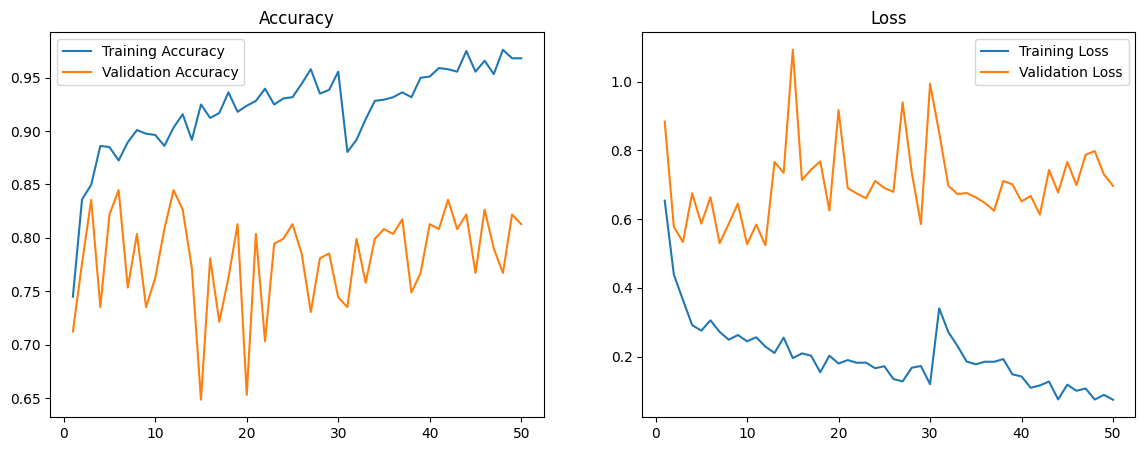

In [12]:
def plot_training(history, history_fine):
    acc = history.history['accuracy'] + history_fine.history['accuracy']
    val_acc = history.history['val_accuracy'] + history_fine.history['val_accuracy']
    loss = history.history['loss'] + history_fine.history['loss']
    val_loss = history.history['val_loss'] + history_fine.history['val_loss']

    epochs = range(1, len(acc) + 1)

    plt.figure(figsize=(14, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, acc, label='Training Accuracy')
    plt.plot(epochs, val_acc, label='Validation Accuracy')
    plt.title('Accuracy')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss, label='Training Loss')
    plt.plot(epochs, val_loss, label='Validation Loss')
    plt.title('Loss')
    plt.legend()

    plt.show()

plot_training(history, history_fine)

In [13]:
model_path = "/kaggle/working/inceptionv3_vit_lungcancer.h5"
hybrid_model.save(model_path)
print(f"\n Model saved successfully at: {model_path}")


 Model saved successfully at: /kaggle/working/inceptionv3_vit_lungcancer.h5


In [14]:
!pip freeze > requirements.txt

In [15]:
!python --version

Python 3.11.13
